# Part 3 – Modeling bus delays (threshold = 1 minute)

This notebook builds and evaluates machine learning models to predict whether a stop event will be delayed by at least 1 minutes.

We:
1. Load the modeling dataset created in the EDA step.
2. Engineer additional volume-based features for routes and stops.
3. Create train/test splits with and without undersampling.
4. Train and compare three models:
   - Logistic Regression (compact, interpretable baseline),
   - Random Forest (full feature set, main model),
   - Gradient Boosting (tree-based alternative).
5. Analyse performance using accuracy, precision, recall, F1, ROC AUC and threshold tuning.
6. Inspect feature importance to connect the model back to the EDA insights.

## 1. Load modeling dataset and add volume features

We start from the modeling CSV produced in the EDA notebook and add two additional features:

- `route_volume`: how many stop events we observe for each route_short_name;
- `stop_volume`: how many stop events we observe for each stop_id.

These volumes approximate how busy each part of the network is.

In [1]:
# 03_model_delay.ipynb
# Part 3 – Modeling bus delays, DELAY_THRESHOLD = 1 minute

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt

# Path to modeling dataset created in 02_eda_delay
DATA_PATH = "../data/df_model_delay.csv"  # adjust if your structure is different

df = pd.read_csv(DATA_PATH)

print("Modeling dataset (delay >= 1) shape:", df.shape)
print(df.head())
print("\nColumns:", df.columns.tolist())
print("\nTarget distribution (is_delayed):")
print(df["is_delayed"].value_counts(normalize=True).rename("proportion"))

Modeling dataset (delay >= 1) shape: (7356700, 14)
     stop_id                                operator  route_id  \
0  201103001  Régime Général des Transports Routiers      3209   
1  201103001  Régime Général des Transports Routiers      3208   
2  201103001  Régime Général des Transports Routiers      3208   
3  201103001  Régime Général des Transports Routiers      3208   
4  201103001  Régime Général des Transports Routiers      3210   

  route_short_name  route_volume  stop_volume  planned_hour  planned_weekday  \
0              413         44076         4567            20                4   
1              412         18202         4567            20                4   
2              412         18202         4567            20                4   
3              412         18202         4567            20                4   
4              501         13828         4567            20                4   

   is_weekend     time_band  rain  is_rainy  is_heavy_rain  is_delayed 

## 2. Feature groups and train/test split

We organise the columns into four feature groups:

- numeric: hour of day, weekday, rain, route_volume, stop_volume;
- binary: weekend and rain flags;
- low-cardinality categorical: operator and time_band;
- high-cardinality categorical: stop_id, route_id and route_short_name.

We then create a stratified train/test split to preserve the real delayed/non-delayed proportions.

In [2]:
# Feature definitions and train/test split (delay >= 1)

TARGET_COL = "is_delayed"

# Separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Feature groups
numeric_features = ["planned_hour", "planned_weekday", "rain", "route_volume", "stop_volume"]
binary_features = ["is_weekend", "is_rainy", "is_heavy_rain"]

# Categorical features
low_card_cat_features = ["operator", "time_band"]
high_card_cat_features = ["stop_id", "route_id", "route_short_name"]

print("Numeric features:", numeric_features)
print("Binary features:", binary_features)
print("Low-cardinality categorical:", low_card_cat_features)
print("High-cardinality categorical:", high_card_cat_features)

# Quick check of cardinalities
print("\nUnique values per feature:")
for col in X.columns:
    print(f"{col}: {X[col].nunique()} unique")

# Stratified split to keep the delay proportion similar in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)

print("\nTarget distribution in train:")
print(y_train.value_counts(normalize=True).rename("proportion"))

print("\nTarget distribution in test:")
print(y_test.value_counts(normalize=True).rename("proportion"))

Numeric features: ['planned_hour', 'planned_weekday', 'rain', 'route_volume', 'stop_volume']
Binary features: ['is_weekend', 'is_rainy', 'is_heavy_rain']
Low-cardinality categorical: ['operator', 'time_band']
High-cardinality categorical: ['stop_id', 'route_id', 'route_short_name']

Unique values per feature:
stop_id: 2494 unique
operator: 5 unique
route_id: 589 unique
route_short_name: 568 unique
route_volume: 435 unique
stop_volume: 1529 unique
planned_hour: 21 unique
planned_weekday: 7 unique
is_weekend: 2 unique
time_band: 5 unique
rain: 28 unique
is_rainy: 2 unique
is_heavy_rain: 2 unique

Train shape: (5885360, 13)  Test shape: (1471340, 13)

Target distribution in train:
is_delayed
0    0.640209
1    0.359791
Name: proportion, dtype: float64

Target distribution in test:
is_delayed
0    0.640209
1    0.359791
Name: proportion, dtype: float64


## 3. Optional undersampling of the majority class

To compare different imbalance strategies, we also create a second training set where:

- all delayed events are kept;
- the same number of on-time events is sampled at random.

The test set remains unchanged so that evaluation always reflects the real-world delay rate.

In [3]:
# Create a balanced (undersampled) training set for experiments

# Boolean masks for delayed and on-time events
mask_delayed = (y_train == 1)
mask_on_time = (y_train == 0)

n_delayed = mask_delayed.sum()
n_on_time = mask_on_time.sum()
print("Number of delayed (train):", n_delayed)
print("Number of on-time (train):", n_on_time)

# Randomly sample on-time events to match the number of delayed events (50/50)
on_time_sampled_idx = (
    y_train[mask_on_time]
    .sample(n=n_delayed, random_state=42, replace=False)
    .index
)

delayed_idx = y_train[mask_delayed].index

# Combine indices and build balanced train set
balanced_idx = delayed_idx.union(on_time_sampled_idx)

X_train_bal = X_train.loc[balanced_idx].copy()
y_train_bal = y_train.loc[balanced_idx].copy()

print("\nBalanced train shape:", X_train_bal.shape)
print("Balanced target distribution:")
print(y_train_bal.value_counts(normalize=True).rename("proportion"))

Number of delayed (train): 2117500
Number of on-time (train): 3767860

Balanced train shape: (4235000, 13)
Balanced target distribution:
is_delayed
1    0.5
0    0.5
Name: proportion, dtype: float64


## 4. Logistic Regression baseline

As a first model we fit a Logistic Regression on a compact feature set:

- time-based features (hour, weekday, weekend flag, time_band),
- rain-related features,
- operator dummies.

We keep the full (imbalanced) training set and use `class_weight="balanced"` so that mistakes on the minority delayed class are penalised more.

Logistic Regression (delay >= 1) – test metrics
Accuracy : 0.5742
Precision: 0.4215
Recall   : 0.4930
F1-score : 0.4545
ROC AUC  : 0.5800

Classification report:
              precision    recall  f1-score   support

           0     0.6851    0.6198    0.6508    941965
           1     0.4215    0.4930    0.4545    529375

    accuracy                         0.5742   1471340
   macro avg     0.5533    0.5564    0.5526   1471340
weighted avg     0.5903    0.5742    0.5802   1471340



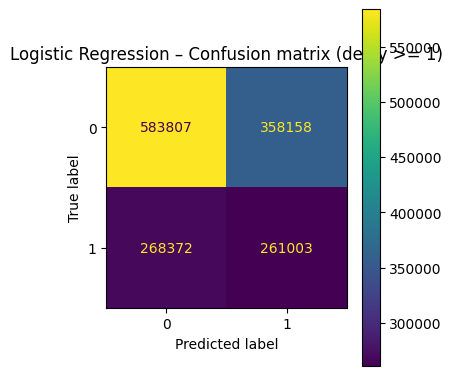

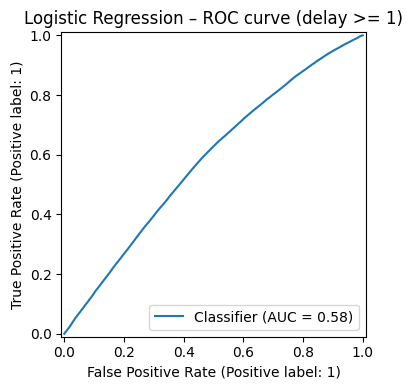

In [4]:
# Logistic Regression model for delay >= 1 minutes
# Uses time + weather + operator + time_band (no large IDs)

from sklearn.metrics import classification_report

# Use only compact, interpretable features for the baseline model
lr_numeric_features = numeric_features              # ['planned_hour', 'planned_weekday', 'rain']
lr_binary_features = binary_features                # ['is_weekend', 'is_rainy', 'is_heavy_rain']
lr_cat_features = low_card_cat_features             # ['operator', 'time_band']

# Use only compact, interpretable features for the baseline model
numeric_transformer = StandardScaler()
binary_transformer = "passthrough"
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine scaling, passthrough and one-hot encoding
lr_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, lr_numeric_features),
        ("bin", binary_transformer, lr_binary_features),
        ("cat", categorical_transformer, lr_cat_features),
    ],
    remainder="drop",
)

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",  # compensate for imbalance
    solver="lbfgs",
)

lr_pipeline = Pipeline(
    steps=[
        ("preprocess", lr_preprocessor),
        ("model", lr_model),
    ]
)

# Fit on the original (imbalanced) training set
lr_pipeline.fit(X_train, y_train)

# Predictions and probabilities on the real-world test set
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

print("Logistic Regression (delay >= 1) – test metrics")
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-score : {f1_lr:.4f}")
print(f"ROC AUC  : {roc_auc_lr:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_lr, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, values_format="d")
ax.set_title("Logistic Regression – Confusion matrix (delay >= 1)")
plt.tight_layout()
plt.show()

# ROC curve
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_lr, ax=ax)
ax.set_title("Logistic Regression – ROC curve (delay >= 1)")
plt.tight_layout()
plt.show()

## 5. Random Forest with full feature set

Next we train a Random Forest classifier that uses:

- all numeric and binary features,
- one-hot encoding for low-cardinality categoricals (operator, time_band),
- ordinal encoding for high-cardinality IDs (stop, route_id, route_short_name).

We keep the original class imbalance and rely on `class_weight` to give more weight to delayed events.

Random Forest (delay >= 1) – test metrics
Accuracy : 0.6770
Precision: 0.5359
Recall   : 0.7627
F1-score : 0.6295
ROC AUC  : 0.7707

Classification report:
              precision    recall  f1-score   support

           0     0.8250    0.6288    0.7137    941965
           1     0.5359    0.7627    0.6295    529375

    accuracy                         0.6770   1471340
   macro avg     0.6805    0.6958    0.6716   1471340
weighted avg     0.7210    0.6770    0.6834   1471340



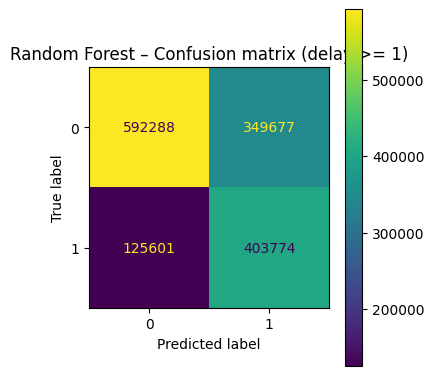

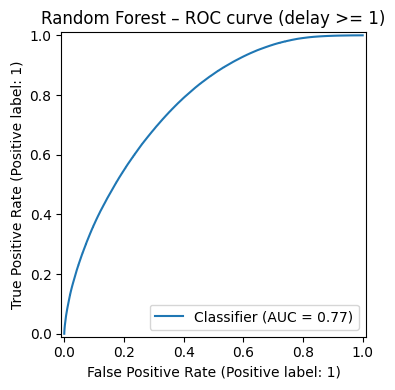

In [5]:
# Random Forest model for delay >= 1 minutes
# Uses all features, including high-cardinality IDs

from sklearn.ensemble import RandomForestClassifier

rf_numeric_features = numeric_features               # ['planned_hour', 'planned_weekday', 'rain']
rf_binary_features = binary_features                 # ['is_weekend', 'is_rainy', 'is_heavy_rain']
rf_low_card_cat_features = low_card_cat_features     # ['operator', 'time_band']
rf_high_card_cat_features = high_card_cat_features   # ['stop_id', 'route_id', 'route_short_name']

# Preprocessing for Random Forest
rf_numeric_transformer = "passthrough"
rf_binary_transformer = "passthrough"
rf_low_card_cat_transformer = OneHotEncoder(handle_unknown="ignore")
rf_high_card_cat_transformer = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", rf_numeric_transformer, rf_numeric_features),
        ("bin", rf_binary_transformer, rf_binary_features),
        ("cat_low", rf_low_card_cat_transformer, rf_low_card_cat_features),
        ("cat_high", rf_high_card_cat_transformer, rf_high_card_cat_features),
    ],
    remainder="drop",
)

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=30,
    min_samples_leaf=75,
    max_features="log2",
    n_jobs=-1,
    class_weight="balanced_subsample",
    random_state=42,
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", rf_preprocessor),
        ("model", rf_model),
    ]
)

# Fit on the original (imbalanced) training set
rf_pipeline.fit(X_train, y_train)

# Evaluate on the real-world test set
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Random Forest (delay >= 1) – test metrics")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"ROC AUC  : {roc_auc_rf:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_rf, digits=4))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 4))
disp_rf.plot(ax=ax, values_format="d")
ax.set_title("Random Forest – Confusion matrix (delay >= 1)")
plt.tight_layout()
plt.show()

# ROC curve
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=ax)
ax.set_title("Random Forest – ROC curve (delay >= 1)")
plt.tight_layout()
plt.show()

Fitting Random Forest on the undersampled training set (delay >= 1 minutes)...

Random Forest (undersampled train, delay >= 1) – test metrics
Accuracy : 0.6850
Precision: 0.5445
Recall   : 0.7621
F1-score : 0.6352
ROC AUC  : 0.7804

Classification report (undersampled RF):
              precision    recall  f1-score   support

           0     0.8276    0.6417    0.7229    941965
           1     0.5445    0.7621    0.6352    529375

    accuracy                         0.6850   1471340
   macro avg     0.6860    0.7019    0.6790   1471340
weighted avg     0.7257    0.6850    0.6913   1471340



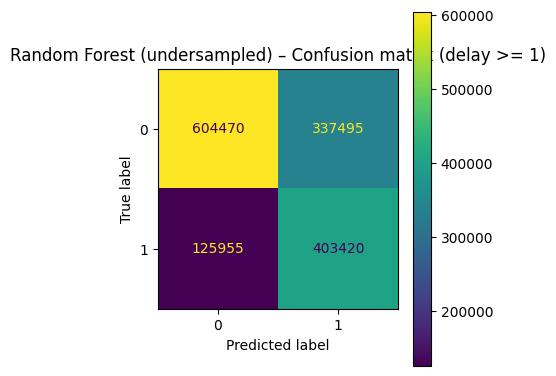

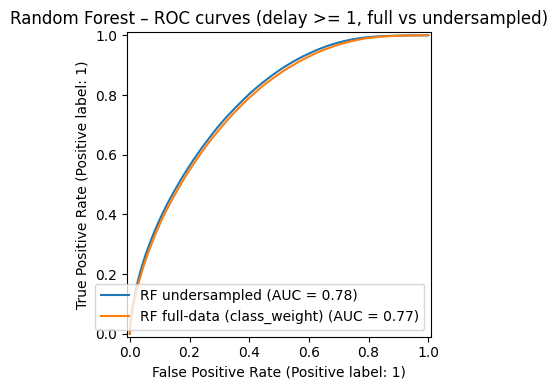

In [6]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest with undersampled training set (delay >= 1 minutes)
# Reuses the same rf_preprocessor but trains on X_train_bal / y_train_bal

rf_under_model = RandomForestClassifier(
    n_estimators=350,      # more trees, closer to the old model
    max_depth=30,       # allow deeper trees
    min_samples_split=2,  # standard splits
    min_samples_leaf=20,   # allow small leaves (more expressive)
    max_features="log2",  # standard RF feature sampling
    n_jobs=-1,
    random_state=42,
    # no class_weight here because the training set is already 50/50
)

rf_under_pipeline = Pipeline(
    steps=[
        ("preprocess", rf_preprocessor),
        ("model", rf_under_model),
    ]
)

print("Fitting Random Forest on the undersampled training set (delay >= 1 minutes)...")
rf_under_pipeline.fit(X_train_bal, y_train_bal)

# Evaluate on the original (imbalanced) test set
y_pred_rf_under = rf_under_pipeline.predict(X_test)
y_proba_rf_under = rf_under_pipeline.predict_proba(X_test)[:, 1]

accuracy_rf_under = accuracy_score(y_test, y_pred_rf_under)
precision_rf_under = precision_score(y_test, y_pred_rf_under, zero_division=0)
recall_rf_under = recall_score(y_test, y_pred_rf_under, zero_division=0)
f1_rf_under = f1_score(y_test, y_pred_rf_under, zero_division=0)
roc_auc_rf_under = roc_auc_score(y_test, y_proba_rf_under)

print("\nRandom Forest (undersampled train, delay >= 1) – test metrics")
print(f"Accuracy : {accuracy_rf_under:.4f}")
print(f"Precision: {precision_rf_under:.4f}")
print(f"Recall   : {recall_rf_under:.4f}")
print(f"F1-score : {f1_rf_under:.4f}")
print(f"ROC AUC  : {roc_auc_rf_under:.4f}")

print("\nClassification report (undersampled RF):")
print(classification_report(y_test, y_pred_rf_under, digits=4))

# Confusion matrix for the undersampled RF
cm_rf_under = confusion_matrix(y_test, y_pred_rf_under)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_rf_under, display_labels=[0, 1]).plot(ax=ax, values_format="d")
ax.set_title("Random Forest (undersampled) – Confusion matrix (delay >= 1)")
plt.tight_layout()
plt.show()

# ROC curve for the undersampled RF
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_rf_under, ax=ax, name="RF undersampled")
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=ax, name="RF full-data (class_weight)")
ax.set_title("Random Forest – ROC curves (delay >= 1, full vs undersampled)")
plt.tight_layout()
plt.show()

## 6. Gradient Boosting on a large subsample

To add a third model family, we train a Gradient Boosting classifier on a random subsample of one million events.

This keeps training time reasonable while providing a strong tree-based baseline to compare with the Random Forest.

In [7]:
# Gradient Boosting model for delay >= 1 minutes
# Uses a compact feature set on a large random subsample of the training data

from sklearn.ensemble import GradientBoostingClassifier

# Features similar to Logistic Regression (no high-card IDs)
gb_numeric_features = numeric_features               # ['planned_hour', 'planned_weekday', 'rain']
gb_binary_features = binary_features                 # ['is_weekend', 'is_rainy', 'is_heavy_rain']
gb_cat_features = low_card_cat_features              # ['operator', 'time_band']

# Preprocessing: trees do not need scaling, one-hot for low-card cats
gb_numeric_transformer = "passthrough"
gb_binary_transformer = "passthrough"
gb_cat_transformer = OneHotEncoder(handle_unknown="ignore")

gb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", gb_numeric_transformer, gb_numeric_features),
        ("bin", gb_binary_transformer, gb_binary_features),
        ("cat", gb_cat_transformer, gb_cat_features),
    ],
    remainder="drop",
)

# Create a random subsample of the training set (keep original class imbalance)
n_gb_samples = 1_000_000  # adjust downwards if training is too slow
if len(X_train) > n_gb_samples:
    gb_sample_idx = y_train.sample(n=n_gb_samples, random_state=42).index
    X_train_gb = X_train.loc[gb_sample_idx].copy()
    y_train_gb = y_train.loc[gb_sample_idx].copy()
else:
    X_train_gb = X_train
    y_train_gb = y_train

print("Gradient Boosting training set shape:", X_train_gb.shape)

# Class weights via sample_weight (balanced)
gb_sample_weight = compute_sample_weight(class_weight="balanced", y=y_train_gb)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.7,
    random_state=42,
)

gb_pipeline = Pipeline(
    steps=[
        ("preprocess", gb_preprocessor),
        ("model", gb_model),
    ]
)

# Fit on the subsampled training data
gb_pipeline.fit(X_train_gb, y_train_gb, model__sample_weight=gb_sample_weight)

# Evaluate on the full test set
y_pred_gb = gb_pipeline.predict(X_test)
y_proba_gb = gb_pipeline.predict_proba(X_test)[:, 1]

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb, zero_division=0)
recall_gb = recall_score(y_test, y_pred_gb, zero_division=0)
f1_gb = f1_score(y_test, y_pred_gb, zero_division=0)
roc_auc_gb = roc_auc_score(y_test, y_proba_gb)

print("Gradient Boosting (delay >= 1) – test metrics")
print(f"Accuracy : {accuracy_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall   : {recall_gb:.4f}")
print(f"F1-score : {f1_gb:.4f}")
print(f"ROC AUC  : {roc_auc_gb:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred_gb, digits=4))

Gradient Boosting training set shape: (1000000, 13)
Gradient Boosting (delay >= 1) – test metrics
Accuracy : 0.5880
Precision: 0.4522
Recall   : 0.6865
F1-score : 0.5452
ROC AUC  : 0.6524

Classification report:
              precision    recall  f1-score   support

           0     0.7514    0.5326    0.6234    941965
           1     0.4522    0.6865    0.5452    529375

    accuracy                         0.5880   1471340
   macro avg     0.6018    0.6095    0.5843   1471340
weighted avg     0.6437    0.5880    0.5952   1471340



In [8]:
# SLIDE 17 FIRST PART
import numpy as np
import pandas as pd

# --- Helpers
def _snapshot():
    return list(globals().items())

def _len(obj):
    try:
        return len(obj)
    except Exception:
        return None

# --- 1) Find candidate models with predict_proba
items = _snapshot()
if hasattr(__builtins__, "print"):
    pass

model_cands = []
for name, obj in items:
    try:
        if not isinstance(name, str) or name.startswith("_"):
            continue
        if hasattr(obj, "predict_proba"):
            cls = type(obj).__name__.lower()
            score = 0
            # Prefer names/objects that look like random forest / pipeline
            if "rf" in name.lower() or "forest" in name.lower() or "random" in name.lower():
                score += 3
            if "pipeline" in cls:
                score += 2
            if "randomforest" in cls or "forest" in cls:
                score += 4
            model_cands.append((score, name, type(obj).__name__))
    except Exception:
        pass

model_cands = sorted(model_cands, reverse=True)

print("Model candidates (best first):")
for s, n, c in model_cands[:10]:
    print(f"  score={s}  {n}  ({c})")

if not model_cands:
    raise RuntimeError(
        "No fitted model with predict_proba() found in this kernel.\n"
        "You are probably in a fresh kernel or a different notebook.\n\n"
        "Fix: open the modeling notebook and run the Random Forest training/evaluation cells first "
        "(or use 'Restart & Run All' in the modeling notebook)."
    )

best_model_name = model_cands[0][1]
rf_pipeline = globals()[best_model_name]
print(f"\n✅ Bound rf_pipeline = {best_model_name}")

# --- 2) Find y_test (binary 0/1, large vector)
items = _snapshot()
y_cands = []
for name, obj in items:
    try:
        if not isinstance(name, str) or name.startswith("_"):
            continue
        if isinstance(obj, (pd.Series, np.ndarray, list)):
            a = np.asarray(obj)
            if a.ndim == 1 and a.size > 1000:
                u = set(np.unique(a[~pd.isna(a)]))
                if u.issubset({0,1}):
                    score = 0
                    if "y" in name.lower(): score += 2
                    if "test" in name.lower(): score += 3
                    y_cands.append((score, name, a.size))
    except Exception:
        pass

y_cands = sorted(y_cands, reverse=True)
print("\ny_test candidates (best first):")
for s, n, L in y_cands[:10]:
    print(f"  score={s}  {n}  (len={L:,})")

if not y_cands:
    raise RuntimeError(
        "No y_test-like vector found in memory.\n"
        "Run the train/test split cell(s) that create y_test, then re-run this cell."
    )

best_y_name = y_cands[0][1]
y_test = np.asarray(globals()[best_y_name]).astype(int)
n_test = len(y_test)
print(f"\n✅ Bound y_test = {best_y_name} (n={n_test:,})")

# --- 3) Find X_test with matching length
items = _snapshot()
X_cands = []
for name, obj in items:
    try:
        if not isinstance(name, str) or name.startswith("_"):
            continue
        if isinstance(obj, (pd.DataFrame, np.ndarray)):
            L = _len(obj)
            if L == n_test:
                score = 0
                if "x" in name.lower(): score += 2
                if "test" in name.lower(): score += 3
                X_cands.append((score, name, type(obj).__name__))
    except Exception:
        pass

X_cands = sorted(X_cands, reverse=True)
print("\nX_test candidates (best first):")
for s, n, t in X_cands[:10]:
    print(f"  score={s}  {n}  ({t})")

if not X_cands:
    raise RuntimeError(
        f"No X_test found with the same length as y_test (n={n_test:,}).\n"
        "Run the train/test split cell(s) that create X_test, then re-run this cell."
    )

best_X_name = X_cands[0][1]
X_test = globals()[best_X_name]
print(f"\n✅ Bound X_test = {best_X_name}")

print("\n✅ Ready. Now you can run the Slide 17 exporter cell that writes:")
print("   rf_threshold_tradeoff.html and rf_confusion_matrix.html")

Model candidates (best first):
  score=7  rf_under_model  (RandomForestClassifier)
  score=7  rf_model  (RandomForestClassifier)
  score=5  rf_under_pipeline  (Pipeline)
  score=5  rf_pipeline  (Pipeline)
  score=3  RandomForestClassifier  (ABCMeta)
  score=2  lr_pipeline  (Pipeline)
  score=2  gb_pipeline  (Pipeline)
  score=0  lr_model  (LogisticRegression)
  score=0  gb_model  (GradientBoostingClassifier)
  score=0  Pipeline  (ABCMeta)

✅ Bound rf_pipeline = rf_under_model

y_test candidates (best first):
  score=5  y_test  (len=1,471,340)
  score=2  y_train_gb  (len=1,000,000)
  score=2  y_train_bal  (len=4,235,000)
  score=2  y_train  (len=5,885,360)
  score=2  y_pred_rf_under  (len=1,471,340)
  score=2  y_pred_rf  (len=1,471,340)
  score=2  y_pred_lr  (len=1,471,340)
  score=2  y_pred_gb  (len=1,471,340)
  score=2  y  (len=7,356,700)
  score=2  mask_delayed  (len=5,885,360)

✅ Bound y_test = y_test (n=1,471,340)

X_test candidates (best first):
  score=5  X_test  (DataFrame)
  sc

In [10]:
# SLIDE 17
import os
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve

OUT_DIR = "../outputs/figures"
os.makedirs(OUT_DIR, exist_ok=True)
OUT_TRADE = os.path.join(OUT_DIR, "rf_threshold_tradeoff.html")
OUT_CM    = os.path.join(OUT_DIR, "rf_confusion_matrix.html")

assert "y_test" in globals(), "y_test not found."
assert "y_proba_rf" in globals(), "y_proba_rf not found."

y_true  = np.asarray(y_test, dtype=int)
y_score = np.asarray(y_proba_rf, dtype=float)

# --- PR curve arrays (threshold-based)
prec, rec, thr = precision_recall_curve(y_true, y_score)
prec_t = prec[1:]
rec_t  = rec[1:]
thr_t  = thr
f1_t   = (2 * prec_t * rec_t) / (prec_t + rec_t + 1e-12)

best_idx = int(np.nanargmax(f1_t))
thr_best = float(thr_t[best_idx])
p_best, r_best, f1_best = float(prec_t[best_idx]), float(rec_t[best_idx]), float(f1_t[best_idx])

# --- Confusion matrix at best threshold
y_hat = (y_score >= thr_best).astype(int)
tn = int(np.sum((y_true == 0) & (y_hat == 0)))
fp = int(np.sum((y_true == 0) & (y_hat == 1)))
fn = int(np.sum((y_true == 1) & (y_hat == 0)))
tp = int(np.sum((y_true == 1) & (y_hat == 1)))

cm = np.array([[tn, fp],
               [fn, tp]], dtype=float)
row_sums = cm.sum(axis=1, keepdims=True) + 1e-12
cm_rowpct = cm / row_sums

text = np.array([
    [f"{tn:,}<br>({cm_rowpct[0,0]*100:.1f}%)", f"{fp:,}<br>({cm_rowpct[0,1]*100:.1f}%)"],
    [f"{fn:,}<br>({cm_rowpct[1,0]*100:.1f}%)", f"{tp:,}<br>({cm_rowpct[1,1]*100:.1f}%)"]
])

print(f"Best-F1 threshold={thr_best:.2f} | F1={f1_best:.3f} P={p_best:.3f} R={r_best:.3f}")

# -----------------------
# Chart A: trade-off curve
# -----------------------
fig_trade = go.Figure()
fig_trade.add_trace(go.Scatter(x=thr_t, y=f1_t,   mode="lines", name="F1 (primary)"))
fig_trade.add_trace(go.Scatter(x=thr_t, y=prec_t, mode="lines", name="Precision"))
fig_trade.add_trace(go.Scatter(x=thr_t, y=rec_t,  mode="lines", name="Recall"))

fig_trade.add_vline(
    x=thr_best, line_dash="dash",
    annotation_text=f"Best F1 @ {thr_best:.2f}",
    annotation_position="top left"
)

fig_trade.update_layout(
    title=dict(text="Operating threshold trade-off (RF, Delayed ≥ 1 min)", x=0.5, font=dict(size=16)),
    xaxis=dict(title="Probability threshold", range=[0,1], dtick=0.1, showgrid=False, zeroline=False),
    yaxis=dict(title="Metric value", range=[0,1], showgrid=True, gridcolor="rgba(255,255,255,0.10)", zeroline=False),
    height=360,
    margin=dict(l=70, r=25, t=90, b=60),  # extra top space prevents overlap with y=1 tick
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="white"),
    legend=dict(
        orientation="h",
        x=0.5, xanchor="center",
        y=1.20, yanchor="top",     # move legend above plot area
        font=dict(size=12)
    )
)

# -----------------------
# Chart B: confusion matrix
# -----------------------
fig_cm = go.Figure(data=go.Heatmap(
    z=cm_rowpct,
    x=["Pred On-time (0)", "Pred Delayed (1)"],
    y=["Actual On-time (0)", "Actual Delayed (1)"],
    text=text,
    texttemplate="%{text}",
    textfont=dict(color="white", size=18),   # ✅ readable text
    hovertemplate="%{y}<br>%{x}<br>Row %: %{z:.3f}<extra></extra>",
    zmin=0, zmax=1,
    colorscale=[
        [0.0, "rgba(255,255,255,0.06)"],
        [1.0, "rgba(56,189,248,0.95)"],
    ],
    xgap=3, ygap=3,  # ✅ clearer cell separation
    showscale=False
))

fig_cm.update_layout(
    title=dict(
        text=f"Confusion matrix @ best-F1 threshold={thr_best:.2f} | F1={f1_best:.3f} P={p_best:.3f} R={r_best:.3f}",
        x=0.5, font=dict(size=16)
    ),
    height=380,
    margin=dict(l=140, r=25, t=90, b=70),
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="white"),
)
fig_cm.update_xaxes(showgrid=False, zeroline=False, tickfont=dict(size=12))
fig_cm.update_yaxes(showgrid=False, zeroline=False, tickfont=dict(size=12))

# --- export with clean wrapper (avoids iframe scrollbars)
def write_clean(fig, path):
    inner = fig.to_html(
        full_html=False,
        include_plotlyjs=True,
        config={"displayModeBar": False, "responsive": True}
    )
    html = f"""<!doctype html>
<html><head><meta charset="utf-8"/>
<style>
html,body{{margin:0;padding:0;overflow:hidden;background:transparent;}}
</style></head><body>{inner}</body></html>"""
    with open(path, "w", encoding="utf-8") as f:
        f.write(html)

write_clean(fig_trade, OUT_TRADE)
write_clean(fig_cm, OUT_CM)

print("Saved:", OUT_TRADE)
print("Saved:", OUT_CM)

Best-F1 threshold=0.46 | F1=0.633 P=0.512 R=0.830
Saved: ../outputs/figures/rf_threshold_tradeoff.html
Saved: ../outputs/figures/rf_confusion_matrix.html


In [11]:
# SLIDE 18
import os
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

OUT_DIR = "../outputs/figures"
os.makedirs(OUT_DIR, exist_ok=True)
OUT_ROC = os.path.join(OUT_DIR, "rf_roc_curve.html")
OUT_PR  = os.path.join(OUT_DIR, "rf_pr_curve.html")

assert "y_test" in globals(), "y_test not found."
assert "y_proba_rf" in globals(), "y_proba_rf not found (use probabilities, not y_pred)."

y_true  = np.asarray(y_test, dtype=int)
y_score = np.asarray(y_proba_rf, dtype=float)

# ---- Sanity check: probabilities should not be constant / binary
u = np.unique(np.round(y_score, 6))
if u.size < 50:
    raise ValueError("y_proba_rf looks wrong (too few unique values). Must be predict_proba[:,1].")

# ---- Compute ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = float(auc(fpr, tpr))

# ---- Compute PR
prec, rec, _ = precision_recall_curve(y_true, y_score)
ap = float(average_precision_score(y_true, y_score))
baseline = float(y_true.mean())  # positive prevalence

print(f"ROC AUC = {roc_auc:.4f}")
print(f"Average Precision (PR AUC) = {ap:.4f}")
print(f"PR baseline (prevalence) = {baseline:.4f}")

# =========================
# Chart 1: ROC curve
# =========================
fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", name=f"RF (AUC={roc_auc:.3f})"))
fig_roc.add_trace(go.Scatter(
    x=[0,1], y=[0,1], mode="lines", name="Random baseline",
    line=dict(dash="dash")
))

fig_roc.update_layout(
    title=dict(text="ROC curve (ranking robustness)", x=0.5, font=dict(size=16)),
    xaxis=dict(title="False Positive Rate", range=[0,1], showgrid=False, zeroline=False),
    yaxis=dict(title="True Positive Rate (Recall)", range=[0,1], showgrid=True,
               gridcolor="rgba(255,255,255,0.10)", zeroline=False),
    height=340,
    margin=dict(l=70, r=25, t=80, b=60),
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="white"),
    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.18, yanchor="top")
)

# =========================
# Chart 2: PR curve
# =========================
fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=rec, y=prec, mode="lines", name=f"RF (AP={ap:.3f})"))
fig_pr.add_trace(go.Scatter(
    x=[0,1], y=[baseline, baseline], mode="lines", name=f"Baseline = {baseline:.3f}",
    line=dict(dash="dash")
))

fig_pr.update_layout(
    title=dict(text="Precision–Recall curve (imbalance-aware)", x=0.5, font=dict(size=16)),
    xaxis=dict(title="Recall", range=[0,1], showgrid=False, zeroline=False),
    yaxis=dict(title="Precision", range=[0,1], showgrid=True,
               gridcolor="rgba(255,255,255,0.10)", zeroline=False),
    height=360,
    margin=dict(l=70, r=25, t=80, b=60),
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="white"),
    legend=dict(orientation="h", x=0.5, xanchor="center", y=1.18, yanchor="top")
)

# ---- Export (no modebar, no iframe scrollbars)
def write_clean(fig, path):
    inner = fig.to_html(
        full_html=False,
        include_plotlyjs=True,
        config={"displayModeBar": False, "responsive": True}
    )
    html = f"""<!doctype html>
<html><head><meta charset="utf-8"/>
<style>html,body{{margin:0;padding:0;overflow:hidden;background:transparent;}}</style>
</head><body>{inner}</body></html>"""
    with open(path, "w", encoding="utf-8") as f:
        f.write(html)

write_clean(fig_roc, OUT_ROC)
write_clean(fig_pr, OUT_PR)

print("Saved:", OUT_ROC)
print("Saved:", OUT_PR)

ROC AUC = 0.7707
Average Precision (PR AUC) = 0.6356
PR baseline (prevalence) = 0.3598
Saved: ../outputs/figures/rf_roc_curve.html
Saved: ../outputs/figures/rf_pr_curve.html


In [14]:
# SLIDE 19
import os, textwrap, warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go

warnings.filterwarnings("ignore", message="X has feature names")

OUT_DIR = "../outputs/figures"
os.makedirs(OUT_DIR, exist_ok=True)
OUT_IMP = os.path.join(OUT_DIR, "rf_feature_importance.html")

assert "X_test" in globals(), "X_test not found."
assert "y_proba_rf" in globals(), "y_proba_rf not found (used to pick the matching RF pipeline)."

X = X_test
y_ref = np.asarray(y_proba_rf, dtype=float)

# 1) Choose the RF pipeline that best matches y_proba_rf (rf_pipeline vs rf_under_pipeline)
candidates = []
for name in ["rf_pipeline", "rf_under_pipeline"]:
    if name in globals():
        est = globals()[name]
        try:
            X_small = X.iloc[:2000]
            p = est.predict_proba(X_small)[:, 1]
            diff = float(np.mean(np.abs(p - y_ref[:len(p)])))
            candidates.append((diff, name, est))
        except Exception:
            pass

if not candidates:
    raise RuntimeError("Could not evaluate rf_pipeline / rf_under_pipeline. Make sure they exist and are fitted.")

candidates.sort(key=lambda t: t[0])
best_diff, best_name, pipe = candidates[0]
print(f"✅ Using estimator: {best_name} (mean|Δproba| vs y_proba_rf ≈ {best_diff:.6f})")

# 2) Extract model feature importances (FAST)
# Pipeline last step is the classifier
clf = pipe.steps[-1][1]
if not hasattr(clf, "feature_importances_"):
    raise RuntimeError(f"{type(clf).__name__} has no feature_importances_.")

importances = np.asarray(clf.feature_importances_, dtype=float)

# 3) Get transformed feature names (after preprocessing)
# This can be many one-hot columns, so we’ll aggregate back to original features.
pre = pipe[:-1]
try:
    feat_names = pre.get_feature_names_out()
except Exception:
    try:
        feat_names = pre.get_feature_names_out(X.columns)
    except Exception:
        feat_names = np.array([f"f{i}" for i in range(len(importances))], dtype=object)

feat_names = np.asarray(feat_names, dtype=object)

# 4) Aggregate one-hot features back to original columns
orig_cols = list(getattr(X, "columns", []))

def base_feature(transformed_name: str) -> str:
    s = transformed_name.split("__", 1)[-1]  # remove transformer prefix (e.g., cat__ / num__)
    # map back to original column if possible
    for c in orig_cols:
        if s == c or s.startswith(c + "_"):
            return c
    # fallback heuristic
    return s.split("_", 1)[0]

df = pd.DataFrame({"feat_raw": feat_names, "imp": importances})
df["feature"] = df["feat_raw"].astype(str).apply(base_feature)
agg = df.groupby("feature", as_index=False)["imp"].sum().sort_values("imp", ascending=False)

top = agg.head(15).copy()
top["imp_pct"] = top["imp"] / (agg["imp"].sum() + 1e-12) * 100.0
top["feature_wrapped"] = top["feature"].astype(str).apply(lambda s: "<br>".join(textwrap.wrap(s, 26)))

# 5) Plot (presentation-ready)
top_plot = top.iloc[::-1]
fig = go.Figure(go.Bar(
    x=top_plot["imp_pct"],
    y=top_plot["feature_wrapped"],
    orientation="h",
    text=top_plot["imp_pct"].round(1).astype(str) + "%",
    textposition="outside",
    cliponaxis=False,
    marker=dict(color="rgba(56,189,248,0.90)")
))

fig.update_layout(
    title=dict(text="Top drivers (RF feature importance, aggregated)", x=0.5, font=dict(size=16)),
    xaxis=dict(title="Share of total importance (%)",
               showgrid=True, gridcolor="rgba(255,255,255,0.10)", zeroline=False),
    yaxis=dict(title="", showgrid=False, zeroline=False),
    height=520,
    margin=dict(l=220, r=40, t=80, b=60),
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    font=dict(color="white")
)

# 6) Export (print-friendly)
inner = fig.to_html(full_html=False, include_plotlyjs=True,
                    config={"displayModeBar": False, "responsive": True})
html = f"""<!doctype html>
<html><head><meta charset="utf-8"/>
<style>html,body{{margin:0;padding:0;overflow:hidden;background:transparent;}}</style>
</head><body>{inner}</body></html>"""
with open(OUT_IMP, "w", encoding="utf-8") as f:
    f.write(html)

print("Saved:", OUT_IMP)

✅ Using estimator: rf_under_pipeline (mean|Δproba| vs y_proba_rf ≈ 0.033548)
Saved: ../outputs/figures/rf_feature_importance.html


In [16]:
# SLIDE 16 (auto-update metrics from current notebook run)
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

OUT_HTML = "../outputs/figures/model_comparison_table.html"

# --- required
assert "y_test" in globals(), "y_test not found. Run the train/test split cells first."
assert "X_test" in globals(), "X_test not found. Run the train/test split cells first."

y_true = np.asarray(y_test).astype(int)
X = X_test

def get_proba(preferred_proba_var: str, fallback_estimator_var: str | None):
    """
    Prefer an existing probability vector (y_proba_*). If missing, compute via estimator.predict_proba(X_test)[:,1].
    """
    if preferred_proba_var in globals():
        p = np.asarray(globals()[preferred_proba_var], dtype=float)
        return p

    if fallback_estimator_var and (fallback_estimator_var in globals()):
        est = globals()[fallback_estimator_var]
        p = est.predict_proba(X)[:, 1]
        return np.asarray(p, dtype=float)

    return None

def metrics_from_proba(p, threshold=0.5):
    y_pred = (p >= threshold).astype(int)
    return {
        "F1": float(f1_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "ROC AUC": float(roc_auc_score(y_true, p)),
    }

# --- define models in the same order/labels as your deck
# Prefer probability arrays if you already computed them in the notebook:
specs = [
    {
        "Model": "Random Forest (class_weight)",
        "Train note": "All data",
        "proba_var": "y_proba_rf",
        "estimator_var": "rf_pipeline",   # fallback only if proba var missing
    },
    {
        "Model": "Random Forest (undersampled train)",
        "Train note": "Balanced train only",
        "proba_var": "y_proba_rf_under",
        "estimator_var": "rf_under_pipeline",
    },
    {
        "Model": "Gradient Boosting",
        "Train note": "1M subsample",
        "proba_var": "y_proba_gb",
        "estimator_var": "gb_pipeline",
    },
    {
        "Model": "Logistic Regression (baseline)",
        "Train note": "All data",
        "proba_var": "y_proba_lr",
        "estimator_var": "lr_pipeline",
    },
]

rows = []
missing = []

for s in specs:
    p = get_proba(s["proba_var"], s["estimator_var"])
    if p is None:
        missing.append((s["Model"], s["proba_var"], s["estimator_var"]))
        continue

    if len(p) != len(y_true):
        raise ValueError(f"{s['Model']}: probability length mismatch (got {len(p)} vs y_test {len(y_true)})")

    m = metrics_from_proba(p, threshold=0.5)  # keep benchmark consistent: same default threshold for all models
    rows.append({"Model": s["Model"], "Train note": s["Train note"], **m})

if missing:
    print("⚠️ Missing models (skipped):")
    for mm in missing:
        print("  -", mm)
    print("Tip: ensure the probability array exists (e.g., y_proba_rf) or the estimator exists (e.g., rf_pipeline).")

if not rows:
    raise RuntimeError("No model rows were generated. Nothing to write.")

df = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)

# --- build the same Plotly table layout you already have
best_idx = int(df["F1"].idxmax())
n = len(df)

def fmt_pct(x): 
    return f"{x*100:.1f}%"

header_fill = "rgba(255,255,255,0.08)"
row_fill_default = "rgba(255,255,255,0.03)"
row_fill_best = "rgba(56,189,248,0.14)"
fills = [(row_fill_best if i == best_idx else row_fill_default) for i in range(n)]

table = go.Table(
    columnwidth=[290, 150, 95, 105, 95, 95],
    header=dict(
        values=["Model", "Train note", "F1", "Precision", "Recall", "ROC AUC"],
        fill_color=header_fill,
        font=dict(color="white", size=16),
        align=["left","left","center","center","center","center"],
        height=44,
    ),
    cells=dict(
        values=[
            df["Model"].tolist(),
            df["Train note"].tolist(),
            [fmt_pct(x) for x in df["F1"]],
            [fmt_pct(x) for x in df["Precision"]],
            [fmt_pct(x) for x in df["Recall"]],
            [f"{x:.3f}" for x in df["ROC AUC"]],
        ],
        fill_color=[fills]*6,
        font=dict(color="white", size=15),
        align=["left","left","center","center","center","center"],
        height=44,
    )
)

fig = go.Figure(data=[table])
fig.update_layout(
    height=640,
    paper_bgcolor="rgba(0,0,0,0)",
    plot_bgcolor="rgba(0,0,0,0)",
    margin=dict(l=10, r=10, t=10, b=10),
)

config = dict(displayModeBar=False, responsive=True)

inner = fig.to_html(full_html=False, include_plotlyjs=True, config=config)
html = f"""<!doctype html>
<html>
<head>
  <meta charset="utf-8"/>
  <meta name="viewport" content="width=device-width, initial-scale=1"/>
  <style>
    html, body {{ height: 100%; margin: 0; padding: 0; overflow: hidden; background: transparent; }}
    #wrap {{ height: 100vh; width: 100vw; }}
    .plotly-graph-div {{ height: 100vh !important; width: 100vw !important; }}
  </style>
</head>
<body>
  <div id="wrap">{inner}</div>
</body>
</html>
"""

os.makedirs(os.path.dirname(OUT_HTML), exist_ok=True)
with open(OUT_HTML, "w", encoding="utf-8") as f:
    f.write(html)

print("Saved:", OUT_HTML)
display(df)

Saved: ../outputs/figures/model_comparison_table.html


,Model,Train note,F1,Precision,Recall,ROC AUC
0,Random Forest (undersampled train),Balanced train only,0.635162,0.544489,0.762068,0.780400
1,Random Forest (class_weight),All data,0.629507,0.535899,0.762737,0.770677
2,Gradient Boosting,1M subsample,0.545219,0.452173,0.686479,0.652441
3,Logistic Regression (baseline),All data,0.454497,0.421543,0.493040,0.579985
